# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [6]:
import sys
import os

sys.path.append("/users/oz22897/atmospherics-tools/fast-osc-feedback")

from fastfeedback import *

In [11]:
import uproot
import pandas as pd
import numpy as np

MAIN_CAF = "/storage/1/st15719/caf_new_sum.2.6M_weighted.root"
PFP_FILE = "reco_pfp_info.root"

P_ENU = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.calo"
P_ELEP = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.lep_calo"
P_PDG = "rec/mc/mc.nu/mc.nu.pdg"

caf_tree = uproot.open(MAIN_CAF)["cafTree"]
data = caf_tree.arrays([P_ENU, P_ELEP, P_PDG])

initial_count = len(data[P_ENU])
print(f"Initial entries in CAF file: {initial_count}")

df_kinematics = pd.DataFrame({
    'E_nu': [x[0] if len(x) > 0 else np.nan for x in data[P_ENU]],
    'E_lep': [x[0] if len(x) > 0 else np.nan for x in data[P_ELEP]],
    'pdg': [x[0] if len(x) > 0 else np.nan for x in data[P_PDG]]
})

df_kinematics['hadron_energy'] = df_kinematics['E_nu'] - df_kinematics['E_lep']
df_kinematics['inelasticity'] = (df_kinematics['E_nu'] - df_kinematics['E_lep']) / df_kinematics['E_nu']
df_kinematics['label'] = (df_kinematics['pdg'] < 0).astype(int)

pfp_tree = uproot.open(PFP_FILE)["reco_pfp_tree"]
df_pfps = pfp_tree.arrays(library="pd")

df_final = pd.concat([df_kinematics, df_pfps], axis=1)

count_pre_filter = len(df_final)
df_final = df_final[df_final['E_nu'] > -998]
count_after_enu = len(df_final)
print(f"Entries discarded by E_nu > -998 filter: {count_pre_filter - count_after_enu}")

df_final = df_final.dropna()
count_after_dropna = len(df_final)
print(f"Entries discarded by dropna(): {count_after_enu - count_after_dropna}")

print(f"\nFinal DataFrame contains {len(df_final)} events.")
print(df_final[['pdg', 'E_nu', 'hadron_energy', 'inelasticity', 'n_reco_pfps']].head())

Initial entries in CAF file: 2884703
Entries discarded by E_nu > -998 filter: 233676
Entries discarded by dropna(): 0

Final DataFrame contains 2651027 events.
   pdg       E_nu  hadron_energy  inelasticity  n_reco_pfps
0  -12  32.386795       3.856979      0.119091           10
1  -12   0.215232      -0.107024     -0.497252            2
2  -14   1.178813      -0.022898     -0.019424            4
4   14   0.507301      -0.086399     -0.170311            3
5   16   0.301862      -0.612872     -2.030306            2


In [ ]:
feature_columns = [
    'E_nu', 'hadron_energy', 'inelasticity', 
    'n_reco_pfps', 'n_reco_tracks', 'n_reco_showers', 
    'single_hits_energy', 'n_reco_muons_pions', 'n_reco_protons'
]

X_data = df_final[feature_columns].values

# believe this labels neutrinos as 0 and anti-neutrinos as 1? 
y_data = (df_final['pdg'] < 0).astype(int).values

([<matplotlib.axis.YTick at 0x7f6e3c837410>,
 [Text(0, -16, '−16'),
  Text(0, -14, '−14'),
  Text(0, -12, '−12'),
  Text(0, 12, '12'),
  Text(0, 14, '14'),
  Text(0, 16, '16')])

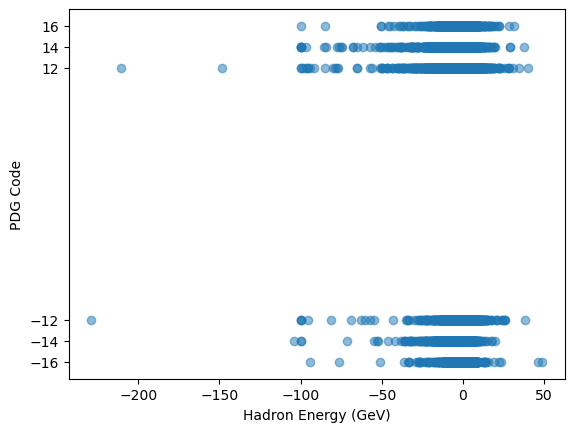

In [ ]:
plt.plot(df_final['hadron_energy'], df_final['pdg'], 'o', alpha=0.5)
plt.xlabel('Hadron Energy (GeV)')
plt.ylabel('PDG Code')
plt.yticks([-16,-14,-12,12,14,16])

([<matplotlib.axis.YTick at 0x7f6e3c7aa300>,
 [Text(0, -16, '−16'),
  Text(0, -14, '−14'),
  Text(0, -12, '−12'),
  Text(0, 12, '12'),
  Text(0, 14, '14'),
  Text(0, 16, '16')])

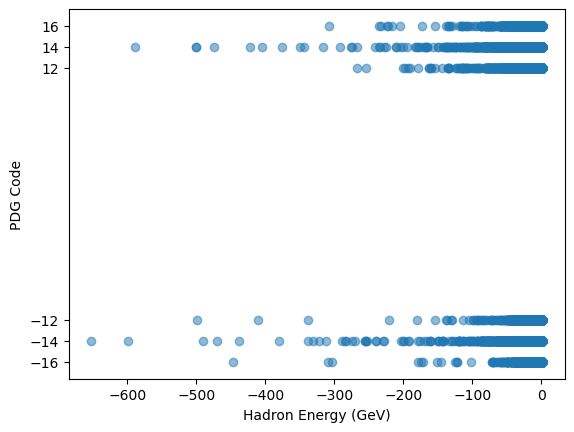

In [ ]:
plt.plot(df_final['inelasticity'], df_final['pdg'], 'o', alpha=0.5)
plt.xlabel('Inelasticity (GeV)')
plt.ylabel('PDG Code')
plt.yticks([-16,-14,-12,12,14,16])

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np


# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [177]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

clf = GradientBoostingClassifier( n_estimators= 100,learning_rate=.6, max_depth=6, random_state=0).fit(X_train, y_train)

KeyboardInterrupt: 

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [169]:
# this will be a value between 0 and 1 for each event, indicating "probability" that the event is anti-neutrino

# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

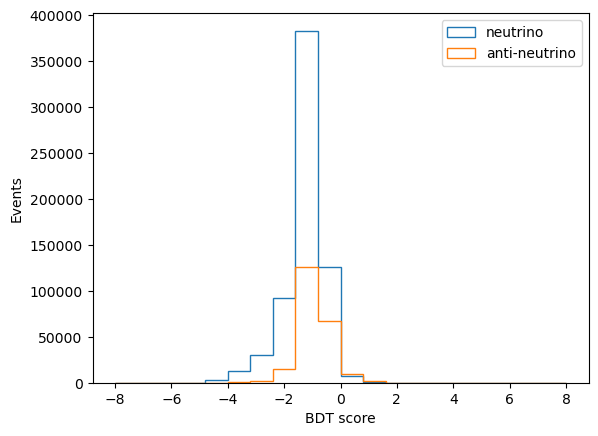

653567.0


In [170]:
n_index = 0 
an_index = 1

n, bins, patches = plt.hist(scores_test[y_test==n_index], label='neutrino', histtype='step', bins=20, range=(-8,8))
plt.hist(scores_test[y_test==an_index], label='anti-neutrino', histtype='step', bins=bins)
plt.legend()
#plt.yscale('log')
plt.xlabel('BDT score')
plt.ylabel('Events')
plt.show()

print(np.sum(n))

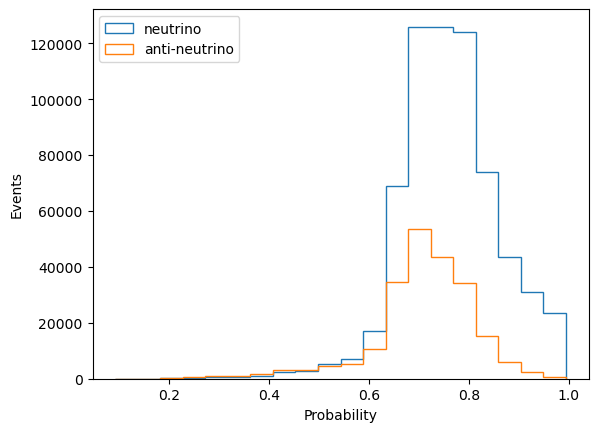

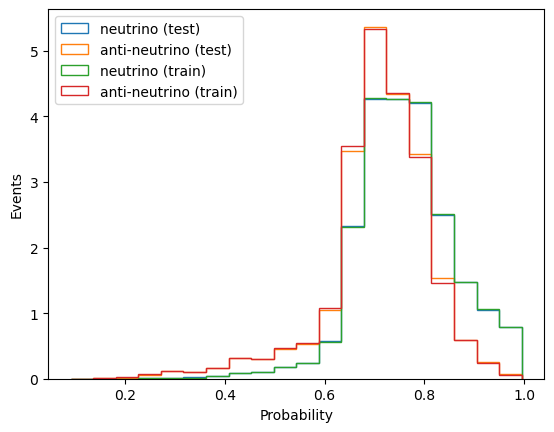

In [171]:

# convert log-odds to probability 
prob_test_n = 1/(1+np.exp(scores_test[y_test==n_index]))
prob_test_an = 1/(1+np.exp(scores_test[y_test==an_index]))
prob_train_n = 1/(1+np.exp(scores_train[y_train==n_index]))
prob_train_an = 1/(1+np.exp(scores_train[y_train==an_index]))

# plot probability distribution for test sample
n, bins, patches = plt.hist(prob_test_n, label='neutrino', histtype='step', bins=20)
plt.hist(prob_test_an, label='anti-neutrino', histtype='step', bins=bins)
plt.legend()
#plt.yscale('log')
plt.xlabel('Probability')
plt.ylabel('Events')
plt.show()

# plot probability distribution for both test and train samples
n, bins, patches = plt.hist(prob_test_n, label='neutrino (test)', histtype='step', bins=20, density=True)
plt.hist(prob_test_an, label='anti-neutrino (test)', histtype='step', bins=bins, density=True)
plt.hist(prob_train_n, label='neutrino (train)', histtype='step', bins=bins, density=True)
plt.hist(prob_train_an, label='anti-neutrino (train)', histtype='step', bins=bins, density=True)
plt.legend()
#plt.yscale('log')
plt.xlabel('Probability')
plt.ylabel('Events')
plt.show()


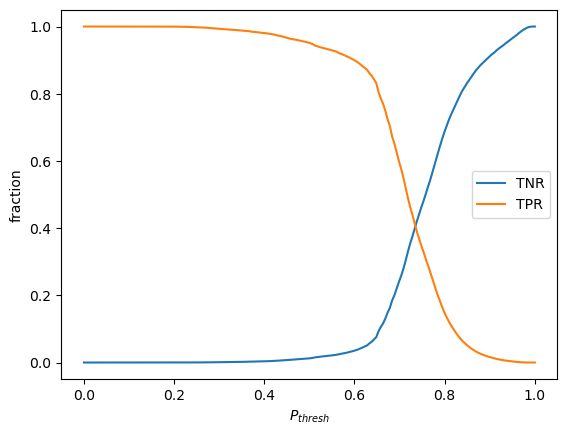

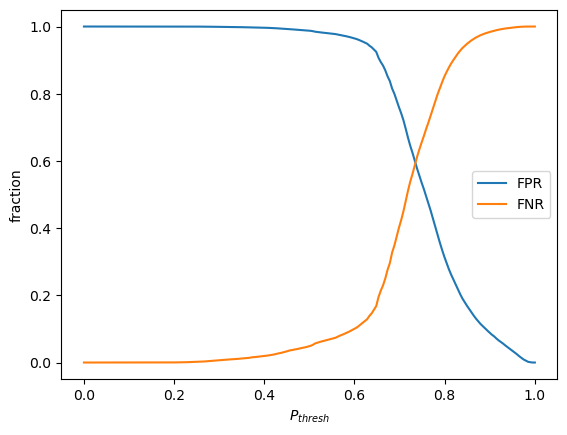

In [172]:


# convert log-odds to probability 
prob_test_h = 1/(1+np.exp(scores_test[y_test==n_index]))
prob_test_g = 1/(1+np.exp(scores_test[y_test==an_index]))
prob_train_h = 1/(1+np.exp(scores_train[y_train==n_index]))
prob_train_g = 1/(1+np.exp(scores_train[y_train==an_index]))


# get arrays of scores for true hadron and gamma classes
score_thresh = np.linspace(0, 1, 200)

# calculate metrics using list comprehension to scan over thresholds
tpr = [ (prob_test_g>score).sum()/len(prob_test_g) for score in score_thresh  ] 
fpr = [ (prob_test_h>score).sum()/len(prob_test_h) for score in score_thresh  ]
tnr = [ (prob_test_h<score).sum()/len(prob_test_h) for score in score_thresh  ] 
fnr = [ (prob_test_g<score).sum()/len(prob_test_g) for score in score_thresh  ] 

# plot TPR/TNR
plt.plot(score_thresh, tnr, label='TNR')
plt.plot(score_thresh, tpr, label='TPR')
plt.legend()
plt.ylabel('fraction')
plt.xlabel('$P_{thresh}$')
plt.show()

# plot FPR/FNR
plt.plot(score_thresh, fpr, label='FPR')
plt.plot(score_thresh, fnr, label='FNR')
plt.legend()
plt.ylabel('fraction')
plt.xlabel('$P_{thresh}$')
plt.show()

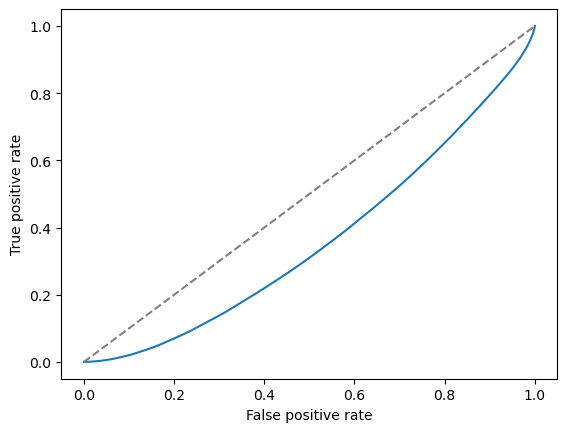

AUC =  0.36104672280748934


/tmp/ipykernel_1559307/1872168995.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(x=fpr[::-1], y=tpr[::-1])


In [173]:
# ROC
plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.plot([0,1],[0,1], linestyle = "--", color = "gray")
plt.show()

#AUC
auc = np.trapz(x=fpr[::-1], y=tpr[::-1])
print("AUC = ",auc)

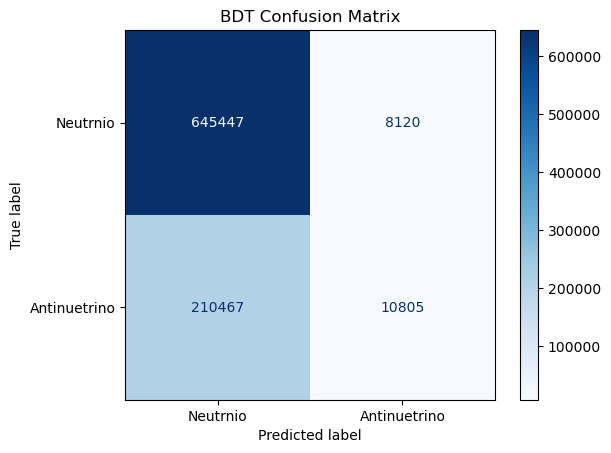

In [175]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



# 1. Generate predictions
y_pred = clf.predict(X_test)

# 2. Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()